### LONGEST COMMON SUBSEQUENCE

In [7]:
import time
import matplotlib.pyplot as plt

### Recursive

In [8]:
def lcs1(s, t, n, m):
    if (n <= 0 or m <= 0):
        return "", 0
    if (s[n - 1] == t[m - 1]):
        st, l = lcs1(s, t, n - 1, m - 1)
        return st + s[n - 1], 1 + l
    else:
        st1, l1 = lcs1(s, t, n - 1, m)
        st2, l2 = lcs1(s, t, n, m - 1)
        if (l1 > l2):
            return st1, l1
        else:
            return st2, l2

### Memoization

In [9]:
def lcs2(s, t, n, m, dp):
    if (n <= 0 or m <= 0):
        return ["", 0]
    
    if (dp[n - 1][m - 1][1] != -1):
        return dp[n - 1][m - 1]

    if (s[n - 1] == t[m - 1]):
        st, val = lcs2(s, t, n - 1, m - 1, dp)
        dp[n - 1][m - 1][0] = st + s[n - 1]
        dp[n - 1][m - 1][1] = 1 + val
    else:
        st1, val1 = lcs2(s, t, n - 1, m, dp)
        st2, val2 = lcs2(s, t, n, m - 1, dp)
        dp[n - 1][m - 1][1] = max(val1, val2)
        if (val1 > val2):
            dp[n - 1][m - 1][0] = st1
        else:
            dp[n - 1][m - 1][0] = st2
    return dp[n - 1][m - 1]

### Tabulation

In [10]:
def lcs3(s, t, n, m, dp):
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if (s[i - 1] == t[j - 1]):
                dp[i][j] = 1 + dp[i - 1][j - 1]
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    st = ""
    i = n
    j = m
    while (i > 0 and j > 0):
        if (s[i - 1] == t[j - 1]):
            st = s[i - 1] + st
            i -= 1
            j -= 1
        else:
            if (dp[i][j - 1] > dp[i - 1][j]):
                j -= 1
            else:
                i -= 1

    return st, dp[n][m]

### Using The Functions

In [11]:
s = input('Enter the first string: ')
t = input('Enter the second string: ')
n = len(s)
m = len(t)


print('Using Recursive Approach . . .')
start = time.perf_counter_ns()
result = lcs1(s, t, n, m)
end = time.perf_counter_ns()
t1 = end - start
print(f'LCS = {result[0]}, length = {result[1]} and time taken is {t1} ns\n')

dp = [[["", -1] for i in range(m)] for j in range(n)]
print('Using Memoization . . .')
start = time.perf_counter_ns()
result = lcs2(s, t, n, m, dp)
end = time.perf_counter_ns()
t2 = end - start
print(f'LCS = {result[0]}, length = {result[1]} and time taken is {t2} ns\n')

dp = [[0 for i in range(m + 1)] for j in range(n + 1)]
print('Using Tabulation . . .')
start = time.perf_counter_ns()
result = lcs3(s, t, n, m, dp)
end = time.perf_counter_ns()
t3 = end - start
print(f'LCS = {result[0]}, length = {result[1]} and time taken is {t3} ns\n')

Using Recursive Approach . . .
LCS = acef, length = 4 and time taken is 6058750 ns

Using Memoization . . .
LCS = acef, length = 4 and time taken is 171667 ns

Using Tabulation . . .
LCS = acef, length = 4 and time taken is 101584 ns



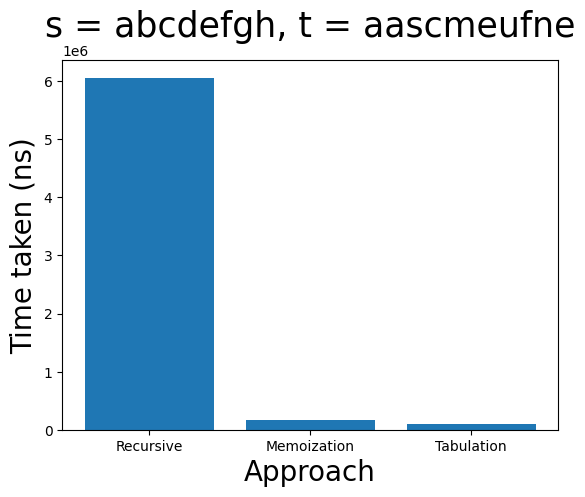

In [12]:
plt.bar(['Recursive', 'Memoization', 'Tabulation'], [t1, t2, t3])
plt.xlabel('Approach', fontsize = 20)
plt.ylabel('Time taken (ns)', fontsize = 20)
plt.title(f's = {s}, t = {t}', fontsize = 25)
plt.show()